In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# Import each training sample, put into matrix so X_tr is (114,1500)
num_sampertype_tr = 5
num_types_tr = 3
num_samples_tr = num_sampertype_tr*num_types_tr
num_feats_tr = 114
num_timesteps_tr = 100
#X_tr = np.zeros((num_samples, num_feats*num_timesteps))
X_tr = np.zeros((num_feats_tr, num_samples_tr*num_timesteps_tr))

types = ['jumping','running','walking']
s = 0
for type in types:
    for i in range(1,num_sampertype_tr+1):
        sample_path = f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/Code/hw2data/train/{type}_{i}.npy'
        sample = np.load(sample_path)
        X_tr[:, s * num_timesteps_tr : (s + 1) * num_timesteps_tr] = sample  # Stack in time direction
        s += 1


In [3]:
# Import each test sample, put into matrix so X_te is (114,300)
num_sampertype_te = 1
num_types_te = num_types_tr
num_samples_te = num_sampertype_te*num_types_te
num_feats_te = num_feats_tr
num_timesteps_te = num_timesteps_tr
X_te = np.zeros((num_feats_te, num_samples_te*num_timesteps_te))

types = ['jumping','running','walking']
s = 0
for type in types:
    for i in range(1,num_sampertype_te+1):
        sample_path = f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/Code/hw2data/test/{type}_1t.npy'
        sample = np.load(sample_path)
        X_te[:, s * num_timesteps_te : (s + 1) * num_timesteps_te] = sample  # Stack in time direction
        s += 1


In [4]:
# Apply PCA with full number of spatial nodes to the training data
pca = PCA()
X_pca = pca.fit_transform(X_tr.T) #reduce dimensions


In [5]:
# Apply PCA fit to test data
X_pca_te = pca.transform(X_te.T) #reduce dimensions
 

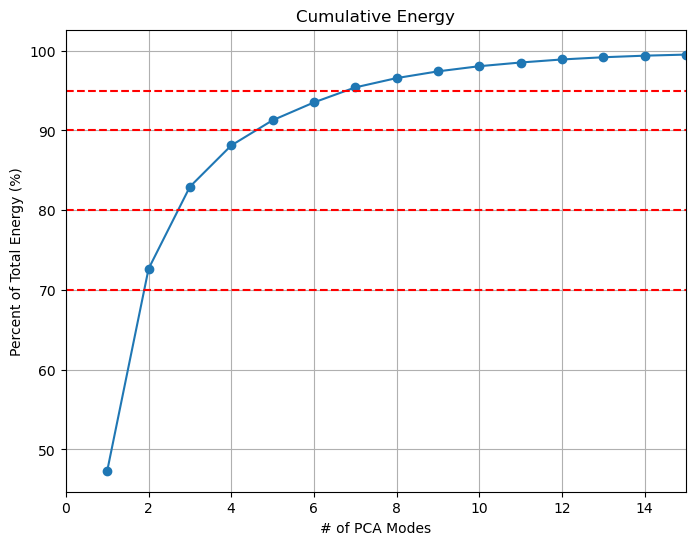

In [11]:
# Task 1, 

# pull out singular values to calculate norm
S = pca.singular_values_
norm_full = (np.sum(S**2))

# apply PCA with approximation (low rank SVD)
x = np.arange(1,num_feats_tr+1)
y = np.zeros(num_feats_tr)
j = 0
for n_nodes in x:
    S_n = S[0:n_nodes]
    norm_approx = (np.sum(S_n**2)) 
    y[j] = (norm_approx/norm_full) * 100
    j+= 1

# plot cumulative energy
plt.figure(figsize=(8,6))

plt.plot(x,y,'o-')
plt.grid()

# add lines are percents in problem statement
percs = [70,80,90,95]
for perc in percs:
    plt.axhline(y=perc, color='r', linestyle='--')

plt.xlabel('# of PCA Modes')

plt.ylabel('Percent of Total Energy (%)')
plt.title('Cumulative Energy')
plt.xlim([0,15])
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/ZoomedCumEnergy.png')
#plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/CumEnergy.png')

Centroid 0, jumping: [-23.88986635 499.36826149]
Centroid 1, running: [  60.77197779 -752.7210869 ]
Centroid 2, walking: [-36.88211143 253.35282541]


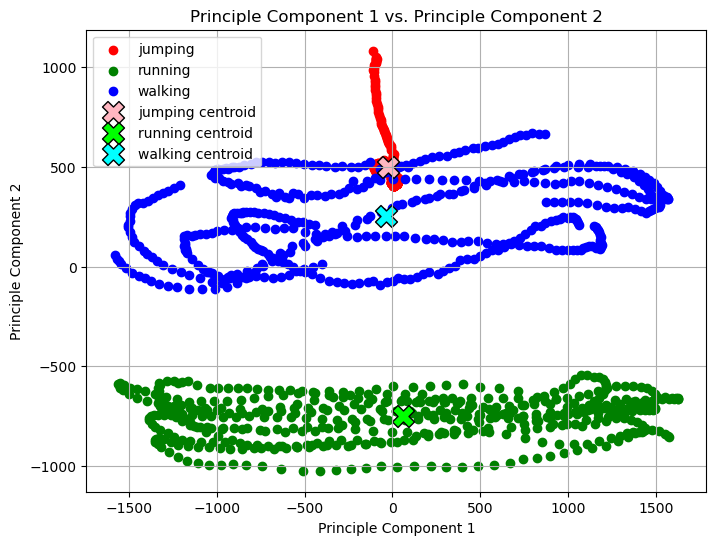

In [151]:
# Task 2a: truncate to 2 modes and plot

# pull out PC1 and PC2
PC1 = X_pca[:,0]
PC2 = X_pca[:,1]

# plot cumulative energy
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot()
plt.grid()

colors = ['r', 'g', 'b']
labels = ['jumping', 'running', 'walking']

for i, activity in enumerate(labels):
    start_idx = i * num_sampertype_tr * num_timesteps_tr   # Each activity has 5 samples, each with 100 timesteps
    end_idx = (i+1) * num_sampertype_tr * num_timesteps_tr
    plt.scatter(PC1[start_idx:end_idx], PC2[start_idx:end_idx], 
                c=colors[i], label=activity)
    
# calculate centroid
k = 2

# make new array of just vectors 1 to k
X_pca_k_tr = X_pca[:,:k]
X_pca_rek_tr = X_pca_k_tr.reshape(num_samples_tr, num_timesteps_tr, k)  # Shape: (15, 100, k)

# create vector of ground truth labels
ground_truth_labs_tr = np.array([0]*num_sampertype_tr + [1]*num_sampertype_tr + [2]*num_sampertype_tr)

# Make an empty dictionary for centroids
centroids = {}

# for each movement, assign them to the centroid dictionary
for movement in [0, 1, 2]:
    movement_samples = X_pca_rek_tr[ground_truth_labs_tr == movement]  # Get samples of this movement
    centroid = np.mean(movement_samples, axis=(0, 1))  # Average over time and samples
    centroids[movement] = centroid

# Plot centroids
centroid_colors = ['lightpink', 'lime', 'cyan']  # Matching original colors
for movement, centroid in centroids.items():
    print(f"Centroid {movement}, {labels[movement]}: {centroid}")
    ax.scatter(*centroid, c=centroid_colors[movement], marker='X', s=250, edgecolors='k', label=f"{labels[movement]} centroid")

plt.legend()
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.title('Principle Component 1 vs. Principle Component 2')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/2D_PC_centroids.png')

0
Plotting jumping: start_idx=0, end_idx=500
1
Plotting running: start_idx=500, end_idx=1000
2
Plotting walking: start_idx=1000, end_idx=1500
Centroid 0, jumping: [-23.88986635 499.36826149 -72.5000755 ]
Centroid 1, running: [  60.77197779 -752.7210869  -103.41194553]
Centroid 2, walking: [-36.88211143 253.35282541 175.91202104]


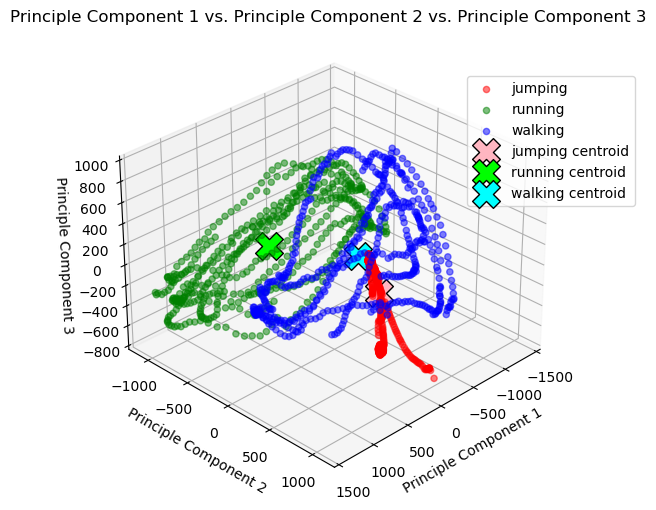

In [163]:
# Task 2b: truncate to 3 modes and plot

# pull out PC3
PC3 = X_pca[:,2]

# plot cumulative energy
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')


colors = ['r', 'g', 'b']
labels = ['jumping', 'running', 'walking']

for i, activity in enumerate(labels):
    print(i)
    start_idx = i * num_sampertype_tr * num_timesteps_tr   # Each activity has 5 samples, each with 100 timesteps
    end_idx = (i+1) * num_sampertype_tr * num_timesteps_tr
    print(f"Plotting {activity}: start_idx={start_idx}, end_idx={end_idx}")  # Debug print
    ax.scatter(PC1[start_idx:end_idx], PC2[start_idx:end_idx], PC3[start_idx:end_idx],
               c=colors[i], label=activity, alpha=0.5)

# calculate centroid
k = 3

# make new array of just vectors 1 to k
X_pca_k_tr = X_pca[:,:k]
X_pca_rek_tr = X_pca_k_tr.reshape(num_samples_tr, num_timesteps_tr, k)  # Shape: (15, 100, k)

# create vector of ground truth labels
ground_truth_labs_tr = np.array([0]*num_sampertype_tr + [1]*num_sampertype_tr + [2]*num_sampertype_tr)

# Make an empty dictionary for centroids
centroids = {}

# for each movement, assign them to the centroid dictionary
for movement in [0, 1, 2]:
    movement_samples = X_pca_rek_tr[ground_truth_labs_tr == movement]  # Get samples of this movement
    centroid = np.mean(movement_samples, axis=(0, 1))  # Average over time and samples
    centroids[movement] = centroid

# Plot centroids
centroid_colors = ['lightpink', 'lime', 'cyan']  # Matching original colors
for movement, centroid in centroids.items():
    print(f"Centroid {movement}, {labels[movement]}: {centroid}")
    ax.scatter(*centroid, c=centroid_colors[movement], marker='X', s=400, edgecolors='k', label=f"{labels[movement]} centroid")

plt.legend(bbox_to_anchor=(0.8, 0.9), loc='upper left', borderaxespad=0)
ax.set_xlabel('Principle Component 1')
ax.set_ylabel('Principle Component 2')
ax.set_zlabel('Principle Component 3')
ax.set_xlim([-1500,1500])
ax.set_ylim([-1200, 1200])
ax.set_zlim([-800, 1000])
ax.view_init(elev=30, azim=45)
plt.title('Principle Component 1 vs. Principle Component 2 vs. Principle Component 3')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/3D_PC_centroids.png')

Plotting jumping: start_idx=0, end_idx=500
Plotting running: start_idx=500, end_idx=1000
Plotting walking: start_idx=1000, end_idx=1500
Centroid 0, jumping: [-23.88986635 499.36826149 -72.5000755 ]


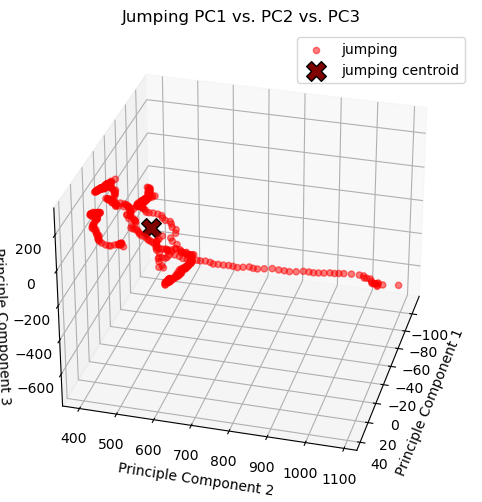

In [58]:
# Task 2b: truncate to 3 modes and plot

# pull out PC3
PC3 = X_pca[:,2]

# plot cumulative energy
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')


colors = ['r', 'g', 'b']
labels = ['jumping', 'running', 'walking']

for i, activity in enumerate(labels):
    start_idx = i * num_sampertype_tr * num_timesteps_tr   # Each activity has 5 samples, each with 100 timesteps
    end_idx = (i+1) * num_sampertype_tr * num_timesteps_tr
    print(f"Plotting {activity}: start_idx={start_idx}, end_idx={end_idx}")  # Debug print
    if i==0:
        ax.scatter(PC1[start_idx:end_idx], PC2[start_idx:end_idx], PC3[start_idx:end_idx],
                c=colors[i], label=activity, alpha=0.5)

# calculate centroid
k = 3

# make new array of just vectors 1 to k
X_pca_k_tr = X_pca[:,:k]
X_pca_rek_tr = X_pca_k_tr.reshape(num_samples_tr, num_timesteps_tr, k)  # Shape: (15, 100, k)

# create vector of ground truth labels
ground_truth_labs_tr = np.array([0]*num_sampertype_tr + [1]*num_sampertype_tr + [2]*num_sampertype_tr)

# Make an empty dictionary for centroids
centroids = {}

# for each movement, assign them to the centroid dictionary
for movement in [0, 1, 2]:
    movement_samples = X_pca_rek_tr[ground_truth_labs_tr == movement]  # Get samples of this movement
    centroid = np.mean(movement_samples, axis=(0, 1))  # Average over time and samples
    centroids[movement] = centroid

# Plot centroids
centroid_colors = ['maroon', 'darkgreen', 'midnightblue']  # Matching original colors
for movement, centroid in centroids.items():
    if movement == 0:
        print(f"Centroid {movement}, {labels[movement]}: {centroid}")
        ax.scatter(*centroid, c=centroid_colors[movement], marker='X', s=200, edgecolors='k', label=f"{labels[movement]} centroid")


plt.legend()
ax.set_xlabel('Principle Component 1')
ax.set_ylabel('Principle Component 2')
ax.set_zlabel('Principle Component 3')
ax.view_init(elev=30, azim=15)
plt.title('Jumping PC1 vs. PC2 vs. PC3')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/3D_PC_jumpingcentroid.png')

Plotting jumping: start_idx=0, end_idx=500
Plotting running: start_idx=500, end_idx=1000
Plotting walking: start_idx=1000, end_idx=1500
Centroid 1, running: [  60.77197779 -752.7210869  -103.41194553]


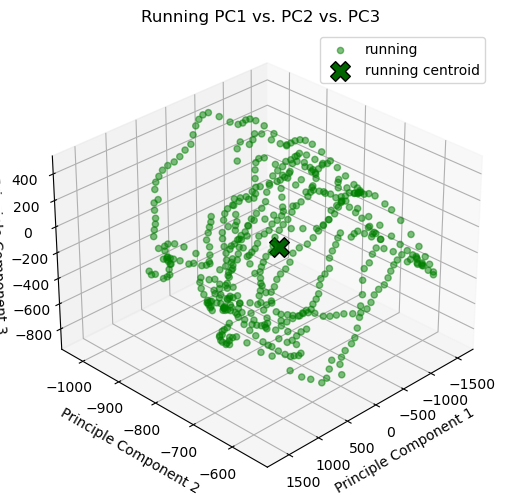

In [43]:
# Task 2b: truncate to 3 modes and plot

# pull out PC3
PC3 = X_pca[:,2]

# plot cumulative energy
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')


colors = ['r', 'g', 'b']
labels = ['jumping', 'running', 'walking']

for i, activity in enumerate(labels):
    start_idx = i * num_sampertype_tr * num_timesteps_tr   # Each activity has 5 samples, each with 100 timesteps
    end_idx = (i+1) * num_sampertype_tr * num_timesteps_tr
    print(f"Plotting {activity}: start_idx={start_idx}, end_idx={end_idx}")  # Debug print
    if i==1:
        ax.scatter(PC1[start_idx:end_idx], PC2[start_idx:end_idx], PC3[start_idx:end_idx],
                c=colors[i], label=activity, alpha=0.5)

# calculate centroid
k = 3

# make new array of just vectors 1 to k
X_pca_k_tr = X_pca[:,:k]
X_pca_rek_tr = X_pca_k_tr.reshape(num_samples_tr, num_timesteps_tr, k)  # Shape: (15, 100, k)

# create vector of ground truth labels
ground_truth_labs_tr = np.array([0]*num_sampertype_tr + [1]*num_sampertype_tr + [2]*num_sampertype_tr)

# Make an empty dictionary for centroids
centroids = {}

# for each movement, assign them to the centroid dictionary
for movement in [0, 1, 2]:
    movement_samples = X_pca_rek_tr[ground_truth_labs_tr == movement]  # Get samples of this movement
    centroid = np.mean(movement_samples, axis=(0, 1))  # Average over time and samples
    centroids[movement] = centroid

# Plot centroids
centroid_colors = ['maroon', 'darkgreen', 'midnightblue']  # Matching original colors
for movement, centroid in centroids.items():
    if movement == 1:
        print(f"Centroid {movement}, {labels[movement]}: {centroid}")
        ax.scatter(*centroid, c=centroid_colors[movement], marker='X', s=200, edgecolors='k', label=f"{labels[movement]} centroid")


plt.legend()
ax.set_xlabel('Principle Component 1')
ax.set_ylabel('Principle Component 2')
ax.set_zlabel('Principle Component 3')
ax.view_init(elev=30, azim=45)
plt.title('Running PC1 vs. PC2 vs. PC3')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/3D_PC_runningcentroid.png')

Plotting jumping: start_idx=0, end_idx=500
Plotting running: start_idx=500, end_idx=1000
Plotting walking: start_idx=1000, end_idx=1500
Centroid 2, walking: [-36.88211143 253.35282541 175.91202104]


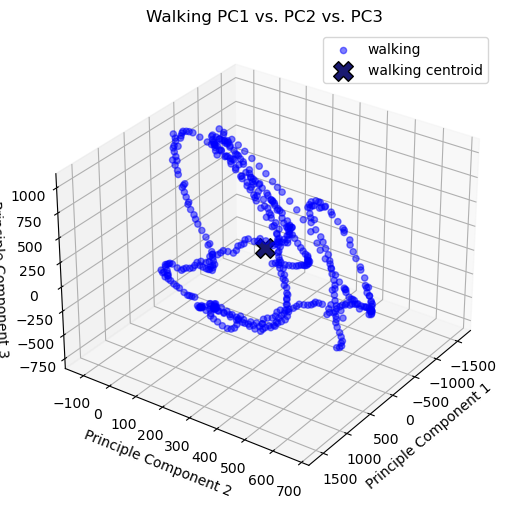

In [153]:
# Task 2b: truncate to 3 modes and plot

# pull out PC3
PC3 = X_pca[:,2]

# plot cumulative energy
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection='3d')


colors = ['r', 'g', 'b']
labels = ['jumping', 'running', 'walking']

for i, activity in enumerate(labels):
    start_idx = i * num_sampertype_tr * num_timesteps_tr   # Each activity has 5 samples, each with 100 timesteps
    end_idx = (i+1) * num_sampertype_tr * num_timesteps_tr
    print(f"Plotting {activity}: start_idx={start_idx}, end_idx={end_idx}")  # Debug print
    if i==2:
        ax.scatter(PC1[start_idx:end_idx], PC2[start_idx:end_idx], PC3[start_idx:end_idx],
                c=colors[i], label=activity, alpha=0.5)

# calculate centroid
k = 3

# make new array of just vectors 1 to k
X_pca_k_tr = X_pca[:,:k]
X_pca_rek_tr = X_pca_k_tr.reshape(num_samples_tr, num_timesteps_tr, k)  # Shape: (15, 100, k)

# create vector of ground truth labels
ground_truth_labs_tr = np.array([0]*num_sampertype_tr + [1]*num_sampertype_tr + [2]*num_sampertype_tr)

# Make an empty dictionary for centroids
centroids = {}

# for each movement, assign them to the centroid dictionary
for movement in [0, 1, 2]:
    movement_samples = X_pca_rek_tr[ground_truth_labs_tr == movement]  # Get samples of this movement
    centroid = np.mean(movement_samples, axis=(0, 1))  # Average over time and samples
    centroids[movement] = centroid

# Plot centroids
centroid_colors = ['maroon', 'darkgreen', 'midnightblue']  # Matching original colors
for movement, centroid in centroids.items():
    if movement == 2:
        print(f"Centroid {movement}, {labels[movement]}: {centroid}")
        ax.scatter(*centroid, c=centroid_colors[movement], marker='X', s=200, edgecolors='k', label=f"{labels[movement]} centroid")


plt.legend()
ax.set_xlabel('Principle Component 1')
ax.set_ylabel('Principle Component 2')
ax.set_zlabel('Principle Component 3')
ax.view_init(elev=30, azim=35)
plt.title('Walking PC1 vs. PC2 vs. PC3')
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/3D_PC_walkingcentroid.png')

In [154]:
# create empty array to store accuracy scores
k_range = np.array([])
scores_tr = np.array([])
scores_te = np.array([])

# Task 3 - create vector of ground truth labels and assign a label to each sample and compute mean
for k in range(1,num_feats_tr+1):
    k_range = np.append(k_range,k)
    # make new array of just vectors 1 to k
    X_pca_k_tr = X_pca[:,:k]
    X_pca_rek_tr = X_pca_k_tr.reshape(num_samples_tr, num_timesteps_tr, k)  # Shape: (15, 100, k)

    # create vector of ground truth labels
    ground_truth_labs_tr = np.array([0]*num_sampertype_tr*num_timesteps_tr + [1]*num_sampertype_tr*num_timesteps_tr + [2]*num_sampertype_tr*num_timesteps_tr)

    #finding centroids for walk, run, jump in this particular k-space
    cen_jump = np.mean(X_pca_k_tr[0:500], axis=0)
    cen_run = np.mean(X_pca_k_tr[500:1000], axis=0)
    cen_walk = np.mean(X_pca_k_tr[1000:1500], axis=0)

    truths = {'Jumping': X_pca_rek_tr[0:500], 'Running': X_pca_rek_tr[500:1000], 'Walking': X_pca_rek_tr[1000:1500]}

    # measure the distance between each value and the centroids
    dist = np.zeros((num_samples_tr*num_timesteps_tr,3))
    # take the norm of each vector minus the centroid
    for i in range(0,num_samples_tr*num_timesteps_tr):
        dist[i,:] = [np.linalg.norm((X_pca_k_tr[i,:]) - cen_jump),
                np.linalg.norm((X_pca_k_tr[i,:]) - cen_run),
                np.linalg.norm((X_pca_k_tr[i,:]) - cen_walk)
                ]
    
    trained_labs = np.argmin(dist, axis=1)
    #print(trained_labs)

    accuracy_tr = accuracy_score(ground_truth_labs_tr, trained_labs)
    scores_tr = np.append(scores_tr,accuracy_tr)


    # LOOK AT TESTING DATA NOW -------------------------------------------------
    # do PCA reduction to k spatial nodes
    X_pca_k_te = X_pca_te[:,:k]
    X_pca_rek_te = X_pca_k_te.reshape(num_samples_te, num_timesteps_te, k)  # Shape: (3, 100, k)

    # create vector of ground truth labels, jumping:0, running:1, walking:2
    ground_truth_labs_te = np.array([0]*num_sampertype_te*num_timesteps_te + [1]*num_sampertype_te*num_timesteps_te + [2]*num_sampertype_te*num_timesteps_te)

    # Task 4 - create another vector of trained labels
    test_labs = np.zeros(num_samples_te)

    # measure the distance between each value and the centroids
    dist = np.zeros((num_samples_te*num_timesteps_te,3))
    # take the norm of each vector minus the centroid
    for i in range(0,num_samples_te*num_timesteps_te):
        dist[i,:] = [np.linalg.norm((X_pca_k_te[i,:]) - cen_jump),
                np.linalg.norm((X_pca_k_te[i,:]) - cen_run),
                np.linalg.norm((X_pca_k_te[i,:]) - cen_walk)
                ]
    
    test_labs = np.argmin(dist, axis=1)

    accuracy_te = accuracy_score(ground_truth_labs_te, test_labs)
    #print(test_labs)
    scores_te = np.append(scores_te,accuracy_te)




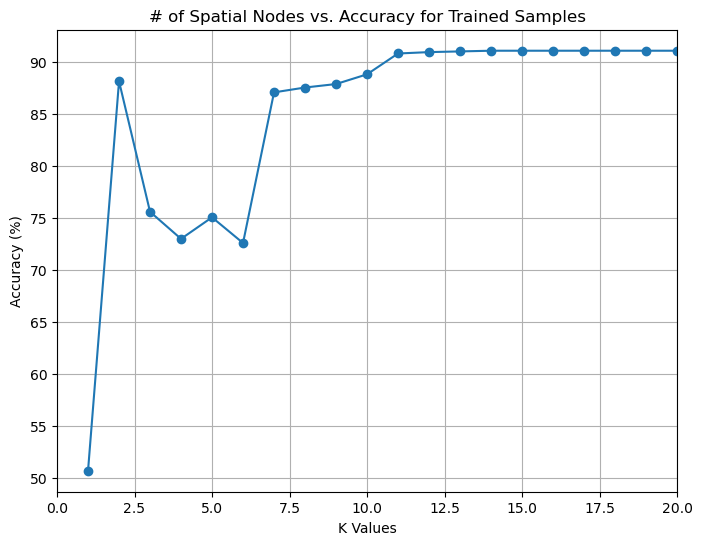

In [155]:
# accuracies for optimal k
plt.figure(figsize=(8,6))

plt.plot(k_range,scores_tr*100,'o-')
plt.xlabel('K Values')
plt.ylabel('Accuracy (%)')

plt.title('# of Spatial Nodes vs. Accuracy for Trained Samples')
plt.grid()
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/train_accuracy_full.png')

plt.xlim([0,20])
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/train_accuracy_zoom.png')

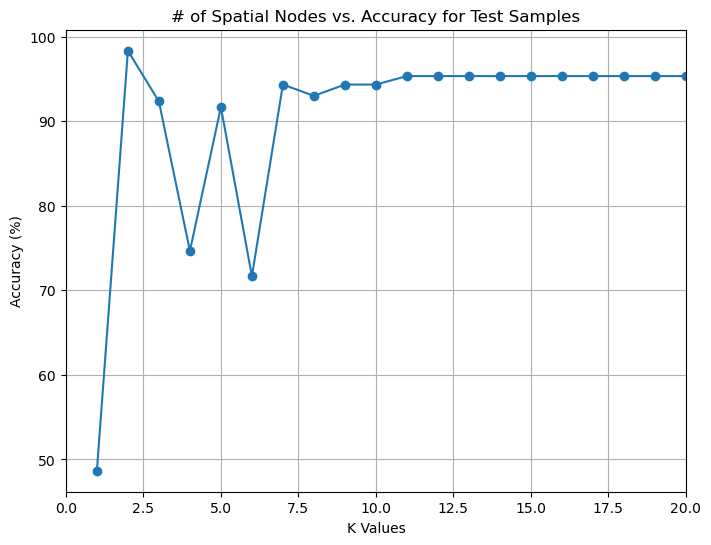

In [95]:
# graph accuracy
# accuracies for optimal k
plt.figure(figsize=(8,6))

plt.plot(k_range,scores_te*100,'o-')
plt.xlabel('K Values')
plt.ylabel('Accuracy (%)')
plt.title('# of Spatial Nodes vs. Accuracy for Test Samples')
plt.grid()
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/test_accuracy_full.png')

plt.xlim([0,20])
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/test_accuracy_zoom.png')

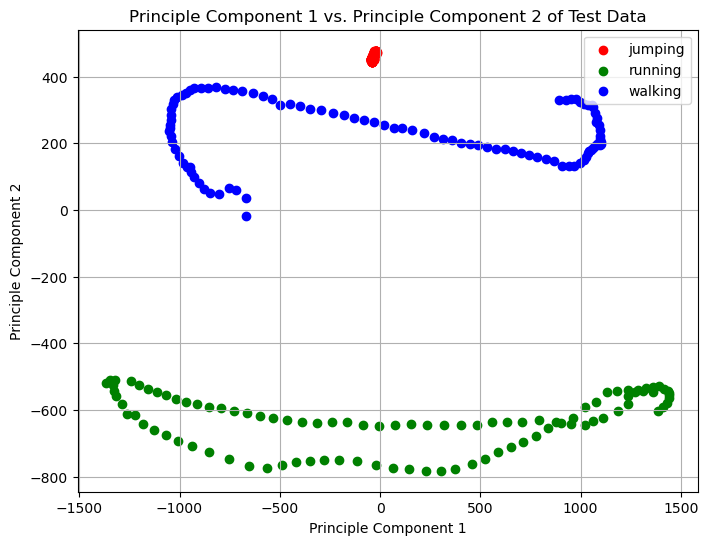

In [96]:
# test data plot in 2D

# pull out PC1 and PC2
PC1_te = X_pca_te[:,0]
PC2_te = X_pca_te[:,1]

# plot cumulative energy
plt.figure(figsize=(8,6))
plt.grid()

colors = ['r', 'g', 'b']
labels = ['jumping', 'running', 'walking']

for i, activity in enumerate(labels):
    start_idx = i * num_sampertype_te * num_timesteps_te   # Each activity has 5 samples, each with 100 timesteps
    end_idx = (i+1) * num_sampertype_te * num_timesteps_te
    plt.scatter(PC1_te[start_idx:end_idx], PC2_te[start_idx:end_idx], 
                c=colors[i], label=activity)

plt.legend()
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.title('Principle Component 1 vs. Principle Component 2 of Test Data')

plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/test_2DPC.png')


0.8813333333333333
0.9833333333333333


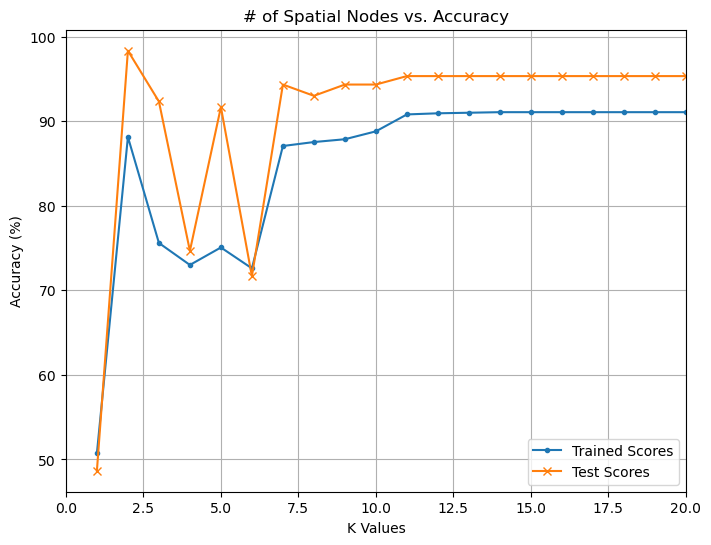

In [159]:
# graph both on same graph
plt.figure(figsize=(8,6))
print(scores_tr[1])
print(scores_te[1])

plt.plot(k_range,scores_tr*100,'.-')
plt.plot(k_range,scores_te*100,'x-')
labels = ['Trained Scores', 'Test Scores']
plt.legend(labels)
plt.xlabel('K Values')
plt.ylabel('Accuracy (%)')

plt.title('# of Spatial Nodes vs. Accuracy')
plt.grid()
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/both_accuracy_full.png')

plt.xlim([0,20])
plt.savefig('/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/both_accuracy_zoom.png')

99.13333333333333
100.0


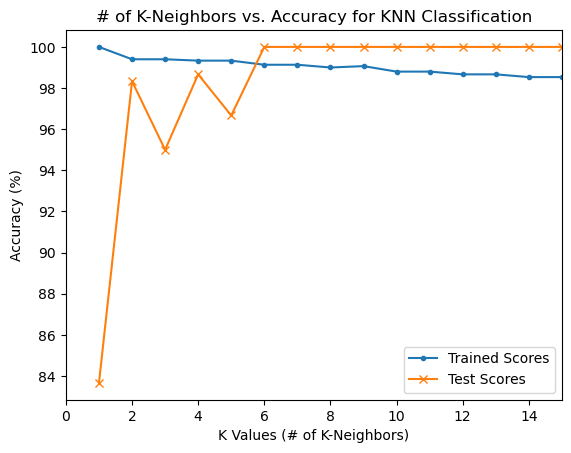

In [160]:
# Extra Credit - KNN Classification
k_optimal = 2

N_neigh_array = np.array(range(1,16))
KNNscores_tr = np.array([])
KNNscores_te = np.array([])
for N_neighbors in N_neigh_array:

    #Perform PCA on Training Data
    pca_KNN = PCA(n_components=k_optimal)
    X_pca_tr_KNN = pca_KNN.fit_transform(X_tr.T)  # Fit PCA to training data

    #Do PCA on Test Data to project data onto k-PCA space
    X_pca_te_KNN = pca_KNN.transform(X_te.T)  # Project test data onto k-PCA space

    # Train k-NN Classifier
    KNN = KNeighborsClassifier(n_neighbors=N_neighbors)
    KNN.fit(X_pca_tr_KNN, ground_truth_labs_tr)  # Train the classifier

    # Get accuracy scores for Train and Test Data
    accuracy_KNN_tr = KNN.score(X_pca_tr_KNN, ground_truth_labs_tr)
    accuracy_KNN_te = KNN.score(X_pca_te_KNN, ground_truth_labs_te)

    # save to arrays
    KNNscores_tr = np.append(KNNscores_tr,accuracy_KNN_tr*100)
    KNNscores_te = np.append(KNNscores_te,accuracy_KNN_te*100)
print(KNNscores_tr[5])
print(KNNscores_te[5])
plt.figure()
plt.plot(N_neigh_array,KNNscores_tr,'.-')
plt.plot(N_neigh_array,KNNscores_te,'x-')
plt.xlabel('K Values (# of K-Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xlim([0,15])
labels = ['Trained Scores', 'Test Scores']
plt.legend(labels)
plt.title(f'# of K-Neighbors vs. Accuracy for KNN Classification')
plt.savefig(f'/Users/jadeg/Documents/UW/winter/AMATH 582/HW2/KNN_Class.png')
